# Dimensionality Reduction

### a) Use the sklearn.decomposition.PCA function to perform dimensionality on some data (e.g.,from your research). Make plots that visualize your principal components.

In [1]:
import h5py
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

f = h5py.File("/Users/relativelyquantum/Programmation/Jupyter/Homework1/Galaxy10_DECals.h5", "r")
galaxy = f["images"]
labels = f["ans"][:]

In [2]:
number_of_galaxy = 50 # We chose to work a restricted number of galaxys/data
idx_class = np.where(labels == 5)[0]  # The class we are working with. 5 is "Barred Spiral Galaxies".
selected_idx = idx_class[:number_of_galaxy]
data = galaxy[selected_idx, 108:148, 108:148, :]
data_flat = data.reshape(data.shape[0], -1)   # we put all our pixel and principale component into a 1D array


Cumulative Variance : 1.0


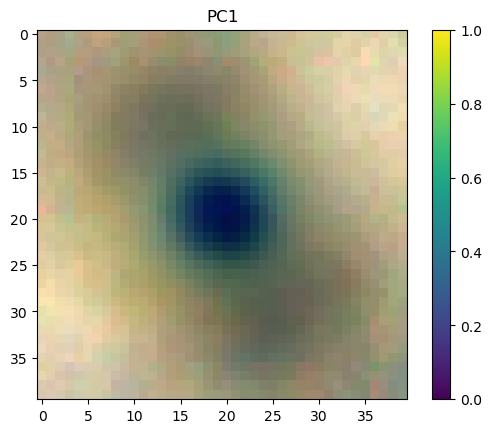

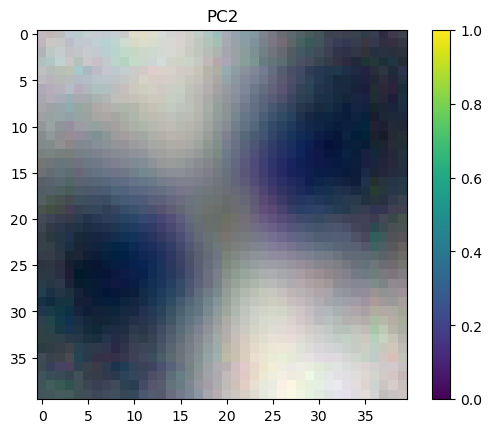

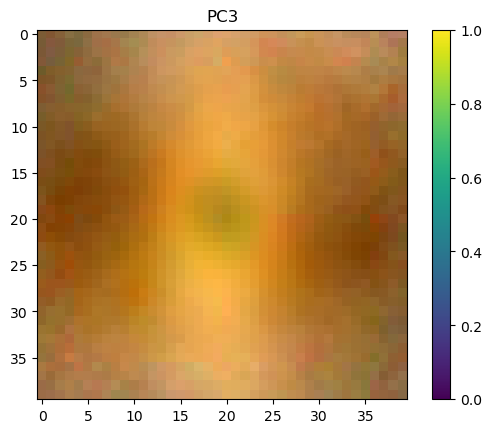

In [3]:
pca = PCA(n_components=50)  # We can chose the number of principal components we want to work with
data_pca = pca.fit_transform(data_flat) # We followed [1]
print('Cumulative Variance :', pca.explained_variance_ratio_.sum()) # We can plot the cumulative variance explained by the PC 

h, w, bands = data.shape[1], data.shape[2], data.shape[3]

pc1 = pca.components_[0].reshape(h, w, bands)
pc2 = pca.components_[1].reshape(h, w, bands)
pc3 = pca.components_[2].reshape(h, w, bands)

def normalize(img):    # We need to normalise our image to plot it whit color bar
    return (img - img.min()) / (img.max() - img.min())

# We will plot the 3 first PCA 
plt.figure()
plt.imshow(normalize(pc1))
plt.title("PC1")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(normalize(pc2))
plt.title("PC2")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(normalize(pc3))
plt.title("PC3")
plt.colorbar()
plt.show()

### b) Make a scree plot to identify the ideal number of principal components that can represent your data.

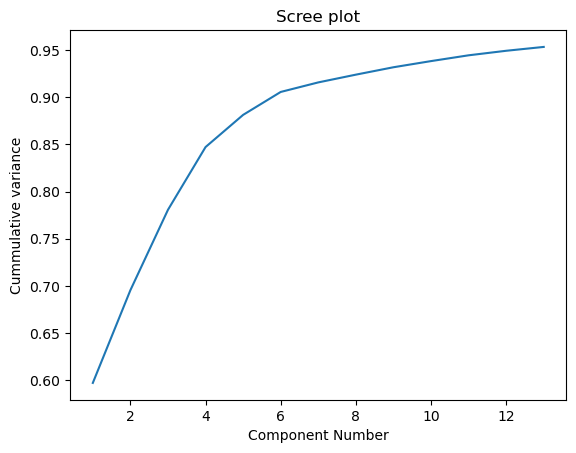

In [4]:
component_number = []
cumulative_variance = []

i = 1
variance_cum = 0

while variance_cum < 0.95: ### In our case 0.95 we will aim to have 95% cummulative variance  
    pca = PCA(n_components=i)
    data_pca = pca.fit_transform(data_flat)
    variance_cum = pca.explained_variance_ratio_.sum()

    component_number.append(i)
    cumulative_variance.append(variance_cum)

    i += 1
plt.plot(component_number, cumulative_variance)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Scree plot')
plt.xlabel('Component Number') 
plt.ylabel('Cummulative variance') 
plt.show()


### c) Plot reconstructions of your data using different numbers of principal components, to show that the reconstruction improves if you use more principal components.

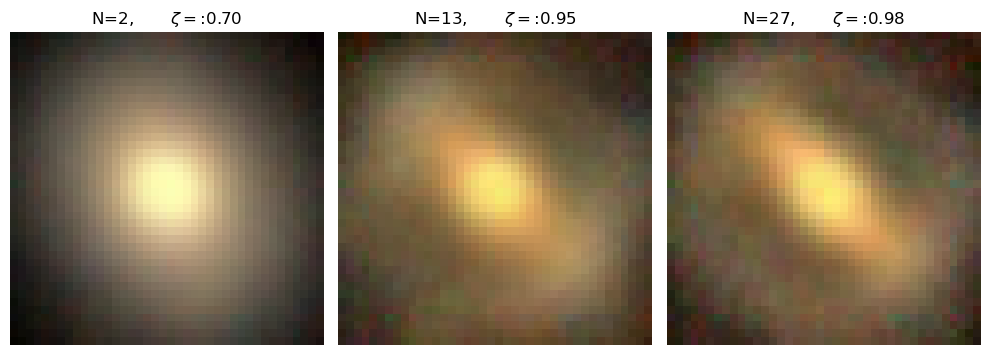

In [5]:
composante_number_0,composante_number_1,composante_number_2 = i-12,i-1,(i*2-1)
pca_0 = PCA(n_components=composante_number_0)
pca_1 = PCA(n_components=composante_number_1)
pca_2 = PCA(n_components=composante_number_2)
data0_pca = pca_0.fit_transform(data_flat)
data1_pca = pca_1.fit_transform(data_flat)
data2_pca = pca_2.fit_transform(data_flat)
reconstruction_0 = pca_0.inverse_transform(data0_pca).reshape(data.shape)
reconstruction_1 = pca_1.inverse_transform(data1_pca).reshape(data.shape)
reconstruction_2 = pca_2.inverse_transform(data2_pca).reshape(data.shape)
# Plot côte à côte
fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(normalize(reconstruction_0[0]))
axes[0].set_title(fr"N={composante_number_0},       $\zeta=$:{f"{cumulative_variance[composante_number_0-1]:.2f}"}")
axes[0].axis("off")

axes[1].imshow(normalize(reconstruction_1[0]))
axes[1].set_title(fr"N={composante_number_1},       $\zeta=$:{f"{cumulative_variance[composante_number_1-1]:.2f}"}")
axes[1].axis("off")

axes[2].imshow(normalize(reconstruction_2[0]))
axes[2].set_title(fr"N={composante_number_2},       $\zeta=$:{f"{pca_2.explained_variance_ratio_.sum():.2f}"}")
axes[2].axis("off")
plt.tight_layout()
plt.show()

We can see that if we limit ourselves to certain PCA results, we see a round galaxy. The concept of “spiral” is not there yet,which appears when we add more PCA.  Here we have set the number of galxy to work with at N=50. We also set the class of galaxy to be 5 (Barred Spiral Galaxies). The result is also interesting ig we change the class to 2 (Round Smooth), 7 (Loose Spiral), and 8 (Edge-on without Bulge). The reconstruction is different (the reverse would be problematic), and we can see the “PCA by class.”

# Reference : 
1. https://builtin.com/machine-learning/pca-in-python?